# Tarea 9 - Procesamiento Distribuido con Apache Spark
### Análisis de Eventos e-Commerce (Dataset OTTO)

**Objetivo:** Utilizar PySpark para procesar y analizar más de 10 millones de interacciones de usuarios en una plataforma de comercio electrónico. Responder preguntas analíticas de negocio sobre tipos de eventos, sesiones de usuarios y comportamiento de productos (vistos, añadidos a carrito y comprados).

## 1. Configuración del Entorno y Carga de Librerías
Importamos las librerías necesarias de **PySpark**, **Pandas**, **Matplotlib** y **Kagglehub**.

In [1]:
import os
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, countDistinct, desc, round as spark_round

## 2. Descarga del Dataset desde Kaggle
Utilizamos `kagglehub` para descargar la versión `train_data_v1.parquet` del dataset **OTTO**.

In [2]:
dataset_path = kagglehub.dataset_download('konradb/otto-dataset-in-dataframe', path='train_data_v1.parquet')
print(f'Ruta del dataset: {dataset_path}')

Ruta del dataset: /home/ubuntu/.cache/kagglehub/datasets/konradb/otto-dataset-in-dataframe/versions/3/train_data_v1.parquet


## 3. Inicialización de la Sesión de Apache Spark
Iniciamos `SparkSession` optimizada para el entorno local, asignando memoria suficiente sin saturar el sistema.

In [3]:
spark = SparkSession.builder \
    .master('local[*]') \
    .appName('Tarea9_OTTO_Analytics') \
    .config('spark.driver.memory', '1500m') \
    .config('spark.sql.shuffle.partitions', '8') \
    .getOrCreate()

print(f'SparkSession activa. Versión de Spark: {spark.version}')

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/11 19:47:36 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


SparkSession activa. Versión de Spark: 4.1.2


## 4. Lectura de Datos en Formato Parquet
Cargamos el archivo Parquet en un DataFrame distribuido de Spark e inspeccionamos el esquema y volumen de datos.

In [4]:
df = spark.read.parquet(dataset_path)
df.printSchema()

total_records = df.count()
print(f'Total de registros cargados: {total_records:,}')

df.show(5, truncate=False)

root
 |-- session: long (nullable = true)
 |-- aid: long (nullable = true)
 |-- ts: long (nullable = true)
 |-- type: string (nullable = true)



Total de registros cargados: 10,285,561


+-------+-------+-------------+------+
|session|aid    |ts           |type  |
+-------+-------+-------------+------+
|0      |1517085|1659304800025|clicks|
|0      |1563459|1659304904511|clicks|
|0      |1309446|1659367439426|clicks|
|0      |16246  |1659367719997|clicks|
|0      |1781822|1659367871344|clicks|
+-------+-------+-------------+------+
only showing top 5 rows


---
## 5. Pregunta 1: ¿Cuántos eventos hay por tipo?
Agrupamos por el campo `type` (`clicks`, `carts`, `orders`) y calculamos el total de eventos y su porcentaje.

+------+-------------+----------+
|  type|total_eventos|porcentaje|
+------+-------------+----------+
|clicks|      9320528|     90.62|
| carts|       751785|      7.31|
|orders|       213248|      2.07|
+------+-------------+----------+



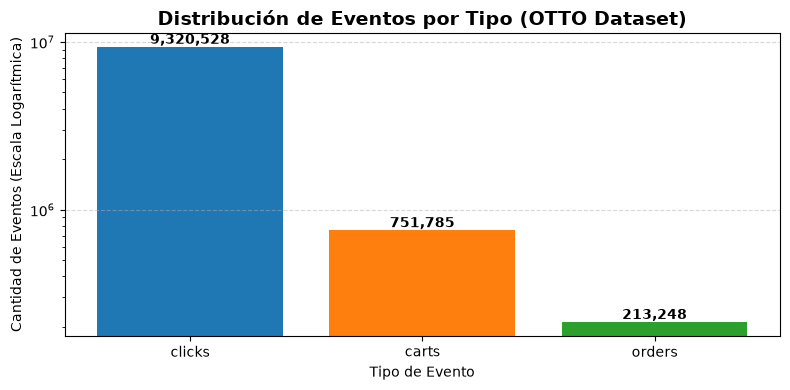

In [5]:
df_events = df.groupBy('type').count() \
    .withColumnRenamed('count', 'total_eventos') \
    .withColumn('porcentaje', spark_round((col('total_eventos') / total_records) * 100, 2)) \
    .orderBy(desc('total_eventos'))

df_events.show()

df_events_pd = df_events.toPandas()
plt.figure(figsize=(8, 4))
bars = plt.bar(df_events_pd['type'], df_events_pd['total_eventos'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Distribución de Eventos por Tipo (OTTO Dataset)', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Evento')
plt.ylabel('Cantidad de Eventos (Escala Logarítmica)')
plt.yscale('log')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{int(yval):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## 6. Pregunta 2: ¿Cuántas sesiones distintas existen?
Determinamos la cardinalidad única de la columna `session` con `countDistinct`.

In [6]:
total_sesiones = df.select(countDistinct('session').alias('total_sesiones_unicas')).collect()[0]['total_sesiones_unicas']
print(f'Número total de sesiones distintas: {total_sesiones:,}')

Número total de sesiones distintas: 200,000


---
## 7. Pregunta 3: ¿Qué sesiones tienen mayor actividad?
Identificamos las sesiones que realizaron el mayor número total de interacciones combinadas.

Top 10 sesiones con mayor actividad:


+-------+-------------------+
|session|total_interacciones|
+-------+-------------------+
|   7905|                495|
| 128925|                494|
|  94753|                493|
|  29248|                493|
| 125985|                492|
|  49196|                491|
|  40216|                490|
| 161528|                489|
| 195390|                489|
|  18239|                488|
+-------+-------------------+



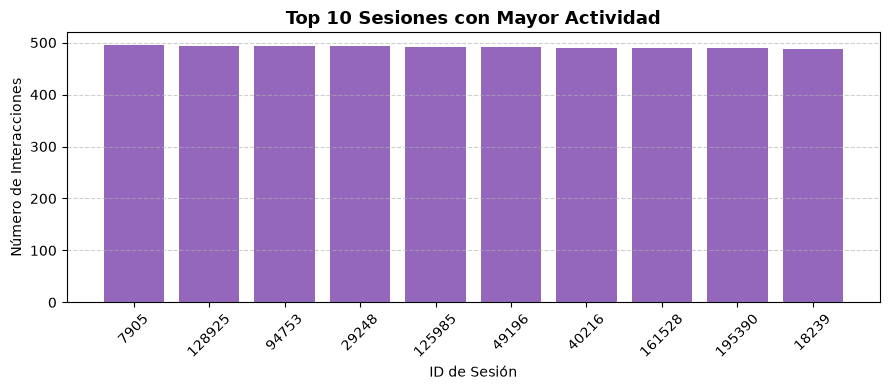

In [7]:
top_sesiones = df.groupBy('session').count() \
    .withColumnRenamed('count', 'total_interacciones') \
    .orderBy(desc('total_interacciones')) \
    .limit(10)

print('Top 10 sesiones con mayor actividad:')
top_sesiones.show()

top_sesiones_pd = top_sesiones.toPandas()
plt.figure(figsize=(9, 4))
plt.bar([str(s) for s in top_sesiones_pd['session']], top_sesiones_pd['total_interacciones'], color='#9467bd')
plt.title('Top 10 Sesiones con Mayor Actividad', fontsize=13, fontweight='bold')
plt.xlabel('ID de Sesión')
plt.ylabel('Número de Interacciones')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

---
## 8. Pregunta 4: ¿Qué productos reciben más clics?
Filtramos los eventos donde `type == 'clicks'` y agrupamos por artículo (`aid`).

Top 10 productos con más clics:


+-------+-----------+
|    aid|total_clics|
+-------+-----------+
|  29735|       5579|
|1603001|       5187|
|1733943|       4756|
| 108125|       4710|
| 832192|       4645|
|1460571|       4098|
| 959208|       3866|
|  80222|       3777|
| 554660|       3770|
| 184976|       3677|
+-------+-----------+



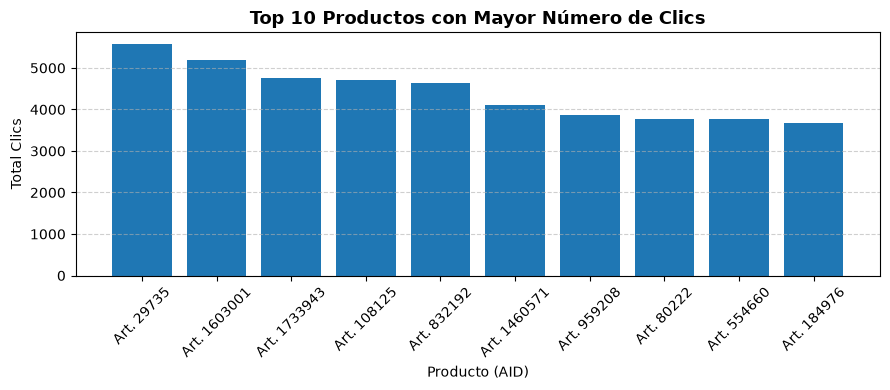

In [8]:
top_clicks = df.filter(col('type') == 'clicks') \
    .groupBy('aid').count() \
    .withColumnRenamed('count', 'total_clics') \
    .orderBy(desc('total_clics')) \
    .limit(10)

print('Top 10 productos con más clics:')
top_clicks.show()

top_clicks_pd = top_clicks.toPandas()
plt.figure(figsize=(9, 4))
plt.bar([f'Art. {a}' for a in top_clicks_pd['aid']], top_clicks_pd['total_clics'], color='#1f77b4')
plt.title('Top 10 Productos con Mayor Número de Clics', fontsize=13, fontweight='bold')
plt.xlabel('Producto (AID)')
plt.ylabel('Total Clics')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

---
## 9. Pregunta 5: ¿Qué productos se agregan más al carrito?
Filtramos las interacciones de tipo `carts` y agrupamos por `aid`.

Top 10 productos más agregados al carrito:


+-------+--------------+
|    aid|total_carritos|
+-------+--------------+
|  80222|           679|
| 166037|           609|
|1733943|           587|
|  29735|           566|
| 485256|           564|
| 832192|           498|
|1022566|           449|
|1603001|           427|
|1672890|           387|
| 152547|           385|
+-------+--------------+



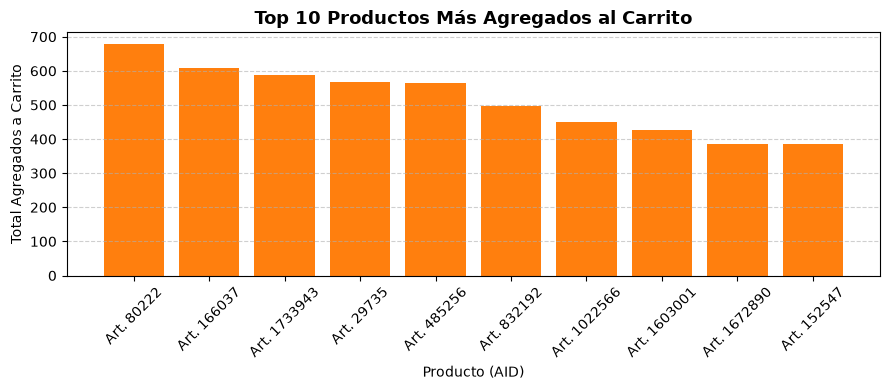

In [9]:
top_carts = df.filter(col('type') == 'carts') \
    .groupBy('aid').count() \
    .withColumnRenamed('count', 'total_carritos') \
    .orderBy(desc('total_carritos')) \
    .limit(10)

print('Top 10 productos más agregados al carrito:')
top_carts.show()

top_carts_pd = top_carts.toPandas()
plt.figure(figsize=(9, 4))
plt.bar([f'Art. {a}' for a in top_carts_pd['aid']], top_carts_pd['total_carritos'], color='#ff7f0e')
plt.title('Top 10 Productos Más Agregados al Carrito', fontsize=13, fontweight='bold')
plt.xlabel('Producto (AID)')
plt.ylabel('Total Agregados a Carrito')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

---
## 10. Pregunta 6: ¿Qué productos terminan siendo comprados?
Filtramos las interacciones de tipo `orders` y agrupamos por `aid`.

Top 10 productos con mayor número de compras:


+-------+-------------+
|    aid|total_compras|
+-------+-------------+
|  80222|          315|
| 351335|          172|
| 166037|          169|
|1022566|          163|
|1603001|          155|
|1629608|          152|
|1733943|          150|
| 231487|          138|
|1445562|          126|
| 332654|          126|
+-------+-------------+



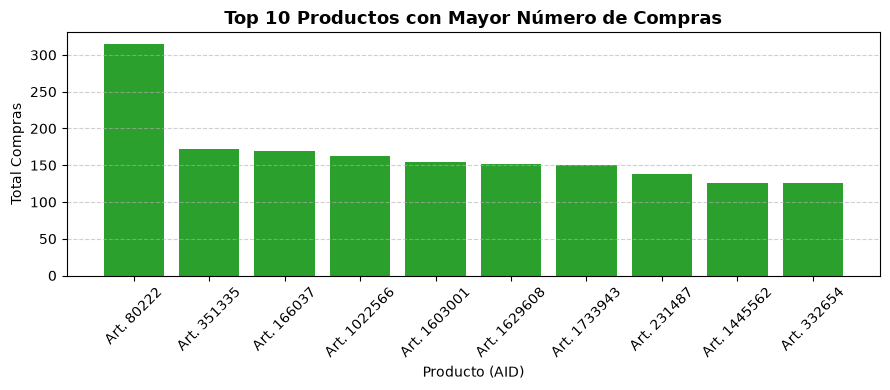

In [10]:
top_orders = df.filter(col('type') == 'orders') \
    .groupBy('aid').count() \
    .withColumnRenamed('count', 'total_compras') \
    .orderBy(desc('total_compras')) \
    .limit(10)

print('Top 10 productos con mayor número de compras:')
top_orders.show()

top_orders_pd = top_orders.toPandas()
plt.figure(figsize=(9, 4))
plt.bar([f'Art. {a}' for a in top_orders_pd['aid']], top_orders_pd['total_compras'], color='#2ca02c')
plt.title('Top 10 Productos con Mayor Número de Compras', fontsize=13, fontweight='bold')
plt.xlabel('Producto (AID)')
plt.ylabel('Total Compras')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

---
## 11. Conclusiones y Resumen del Funnel de Conversión
Analizamos el comportamiento global del embudo de conversión.

In [11]:
clicks_cnt = df_events_pd.loc[df_events_pd['type'] == 'clicks', 'total_eventos'].values[0]
carts_cnt = df_events_pd.loc[df_events_pd['type'] == 'carts', 'total_eventos'].values[0]
orders_cnt = df_events_pd.loc[df_events_pd['type'] == 'orders', 'total_eventos'].values[0]

print('=' * 50)
print('           MÉTRICAS DEL FUNNEL DE CONVERSIÓN')
print('=' * 50)
print(f'Total Clics:               {clicks_cnt:,}')
print(f'Total Carritos:            {carts_cnt:,} ({carts_cnt/clicks_cnt*100:.2f}% de clics)')
print(f'Total Compras:             {orders_cnt:,} ({orders_cnt/carts_cnt*100:.2f}% de carritos)')
print(f'Tasa de Conversión Total:  {orders_cnt/clicks_cnt*100:.2f}%')
print('=' * 50)

spark.stop()
print('Sesión de Spark finalizada exitosamente.')

           MÉTRICAS DEL FUNNEL DE CONVERSIÓN
Total Clics:               9,320,528
Total Carritos:            751,785 (8.07% de clics)
Total Compras:             213,248 (28.37% de carritos)
Tasa de Conversión Total:  2.29%
Sesión de Spark finalizada exitosamente.
